In [22]:
import json
import pandas as pd
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pylab as plt

from sklearn.preprocessing import StandardScaler

result = []

for seed in range(30,50):
    
    target_variable = ['max_uz']

    fea_df = pd.read_csv(f'../data/fea_output_{seed}.csv')
    x_test = np.asarray(fea_df.drop(columns=target_variable))
    y_test = np.asarray(fea_df[target_variable])
    
    fath = f'GP_AL_results_seed_{seed}_fea_or.json'
    with open(fath, "r") as f:
        data = json.load(f)
    for step in range(0,20):
        scaler = StandardScaler()
        
        X_train = np.asarray(data[step]['X_train'])
        y = np.asarray(data[step]['y_train']).ravel()
        X_train_scaled = scaler.fit_transform(X_train)
        x_test_scaled = scaler.transform(x_test)
        from sklearn.ensemble import RandomForestRegressor
        model = RandomForestRegressor(random_state=seed)
        model.fit(X_train_scaled, y)
        y_pred = model.predict(x_test_scaled)
        r2 = r2_score(y_test, y_pred)
        result.append(
            {
                'seed':seed,
                'step':step,
                'r2':r2
            }
        )


In [34]:
df = pd.DataFrame(result)
mean_r2 = df.groupby('step', as_index=False)['r2'].mean()

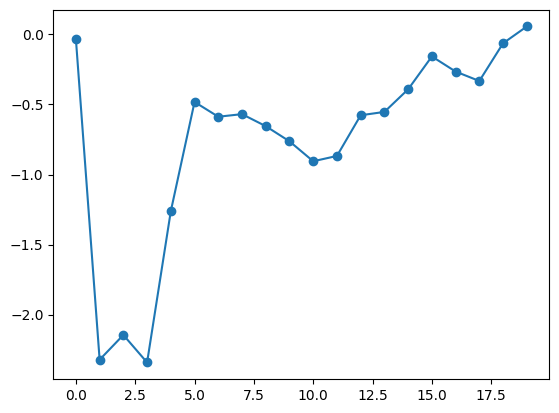

In [38]:
plt.figure()
plt.plot(mean_r2['step'], mean_r2['r2'], marker='o')